# Returns and Corporate-Action Forensics
## Experiment B — Cash Dividends

### Research question

How does ignoring cash dividends distort measured returns, cumulative wealth, and the interpretation of dividend-date price movements?

### Why this matters

A stock price can fall when the stock begins trading without entitlement
to an upcoming dividend. That price decline does not nece$$arily represent
a lo$$ to the shareholder because the investor receives cash separately.

In this notebook, we:

1. verify the accounting with a deterministic synthetic example
2. construct price and total returns for Coca-Cola
3. reconcile explicit dividend accounting with yfinance adjusted close
4. quantify the long-run wealth omitted by price-only returns
5. identify dates on which price return and investor return have different signs


# 1. Financial background

A cash dividend is a distribution paid by a company to its shareholders.

Relevant dates include:

- **Declaration date:** the company announces the dividend.
- **Ex-dividend date:** a buyer purchasing the stock on or after this date
  does not receive the declared dividend.
- **Record date:** the company identifies eligible shareholders.
- **Payment date:** the cash is distributed.

For daily return accounting, vendors commonly associate the dividend with
the ex-dividend date.

The price-only return is

$$
r_t^{\mathrm{price}}
=
\frac{P_t}{P_{t-1}}-1.
$$

If the shareholder receives cash dividend $D_t$, the one-period total
return is

$$
r_t^{\mathrm{total}}
=
\frac{P_t+D_t}{P_{t-1}}-1.
$$

Therefore,

$$
r_t^{\mathrm{total}}-r_t^{\mathrm{price}}
=
\frac{D_t}{P_{t-1}}.
$$

The price may move for many reasons on the ex-dividend date. It is not
expected to fall by exactly the dividend amount because ordinary market
movements occur simultaneously.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

def find_project_root(start: Path) -> Path:
    """Find the nearest parent directory containing pyproject.toml."""
    resolved_start = start.resolve()

    for candidate in (resolved_start, *resolved_start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root containing pyproject.toml."
    )


project_root = find_project_root(Path.cwd())
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from returns_forensics.returns import (
    simple_returns,
    total_returns,
)

# 2. Synthetic dividend identity

Before using vendor data, we construct a case whose economic answer is known
exactly.

Suppose a stock closes at \$100, pays a \$1 dividend, and then trades at
\$99. The raw price return is

$$
\frac{99}{100}-1=-1\%,
$$

but the shareholder's total return is

$$
\frac{99+1}{100}-1=0\%.
$$

The following three-date example also shows that subsequent returns compound
from the new ex-dividend price.

In [2]:
dates = pd.bdate_range(start="2024-03-01", periods=3, name="date",)

dividend_df = pd.DataFrame(
    {
        "date": dates,
        "raw_price": [100.0, 99.0, 100.0],
        "cash_dividend": [0.0, 1.0, 0.0],
    }
)

dividend_df['price_return'] = simple_returns(dividend_df['raw_price'])
dividend_df['total_return'] = total_returns(dividend_df['raw_price'], dividend_df['cash_dividend'])
dividend_df['dividend_return_component'] = dividend_df['cash_dividend'] / dividend_df['raw_price'].shift(1)

dividend_df["price_growth_factor"] = (1.0 + dividend_df["price_return"].fillna(0.0)).cumprod()
dividend_df["total_return_growth_factor"] = (1.0 + dividend_df["total_return"].fillna(0.0)).cumprod()

dividend_df

,date,raw_price,cash_dividend,price_return,total_return,dividend_return_component,price_growth_factor,total_return_growth_factor
0,2024-03-01,100.0,0.0,NaN,NaN,NaN,1.00,1.000000
1,2024-03-04,99.0,1.0,-0.010000,0.000000,0.01,0.99,1.000000
2,2024-03-05,100.0,0.0,0.010101,0.010101,0.00,1.00,1.010101


In [3]:
np.testing.assert_allclose(
    dividend_df["total_return"] - dividend_df["price_return"],
    dividend_df["dividend_return_component"],
)

np.testing.assert_allclose(
    dividend_df["total_return_growth_factor"].iloc[-1],
    100.0 / 99.0,
)

np.testing.assert_allclose(
    dividend_df.loc[2,"total_return_growth_factor"],
    100/99,
)

In [4]:
output_dir = project_root / "data" / "raw" / "synthetic"
output_dir.mkdir(parents=True, exist_ok=True)
base_columns = ["date", "raw_price", "cash_dividend"]

output_path = output_dir / "synthetic_dividend.csv"
dividend_df[base_columns].to_csv(output_path, index=False)

### Interpretation

On the ex-dividend date, the price-only series records a 1% loss, while
total return is zero. The following day's return is positive because the
price rises from \$99 to \$100.

The total-return growth index ends above one because it treats the dividend
as part of investor wealth and compounds subsequent returns from the
ex-dividend price.

# 3. Real-data experiment: Coca-Cola

## Data provenance

- Provider: yfinance
- Symbol: `KO`
- Interval: daily
- Requested period: 2023-01-01 through 2026-01-01
- End-date convention: exclusive
- `auto_adjust=False`
- `actions=True`
- Raw close, adjusted close, dividends, and stock splits are retained
- Retrieval script: `scripts/download_yfinance.py`

The downloaded sample contains 752 observations, 12 dividend events, and no
stock splits. Dividend values are vendor-supplied event fields associated
with the ex-dividend date.

The analysis ignores taxes, transaction costs, and differences in actual
dividend reinvestment timing.

In [5]:
raw_path = (
    project_root
    / "data"
    / "raw"
    / "yfinance"
    / "KO_2023-01-01_2026-01-01.csv"
)

ko = pd.read_csv(raw_path)

ko["date"] = (
    pd.to_datetime(ko["date"], utc=True)
    .dt.tz_convert("America/New_York")
    .dt.normalize()
    .dt.tz_localize(None)
)

ko = ko.rename(
    columns={
        "Close": "close_raw",
        "Adj Close": "adj_close",
        "Dividends": "cash_dividend",
        "Stock Splits": "stock_split",
    }
)

In [6]:
data_audit = pd.Series(
    {
        "first_date": ko["date"].min(),
        "last_date": ko["date"].max(),
        "number_of_rows": len(ko),
        "dividend_events": ko["cash_dividend"].gt(0).sum(),
        "split_events": ko["stock_split"].gt(0).sum(),
        "duplicate_dates": ko["date"].duplicated().sum(),
    }
)

display(data_audit.to_frame("value"))

,value
first_date,2023-01-03 00:00:00
last_date,2025-12-31 00:00:00
number_of_rows,752
dividend_events,12
split_events,0
duplicate_dates,0


In [7]:
annual_dividends = (
    ko.assign(year=ko["date"].dt.year)
    .groupby("year")["cash_dividend"]
    .sum()
    .to_frame("dividend_per_share")
)

display(annual_dividends)

,dividend_per_share
year,
2023,1.84
2024,1.94
2025,2.04


# 5. Return construction and vendor reconciliation

We compare three return series.

### 1. Raw price return

$$
r_t^{\mathrm{price}}
=
\frac{P_t}{P_{t-1}}-1.
$$

This excludes cash distributions.

### 2. Total return from explicit action fields

$$
r_t^{\mathrm{actions}}
=
\frac{P_t+D_t}{P_{t-1}}-1.
$$

This uses the raw close and the dividend supplied by the vendor.

### 3. Adjusted-close return

$$
r_t^{\mathrm{adj}}
=
\frac{A_t}{A_{t-1}}-1,
$$

where $A_t$ is the vendor's back-adjusted close.

Adjusted close is an analytical series. It is not the price quoted in the
market on that historical date.

The reconciliation error is defined as

$$
e_t
=
r_t^{\mathrm{actions}}-r_t^{\mathrm{adj}}.
$$

In [8]:
ko["price_return"] = simple_returns(ko["close_raw"])

ko["total_return_from_actions"] = total_returns(
    prices=ko["close_raw"],
    cash_dividends=ko["cash_dividend"],
)

ko["adjusted_close_return"] = simple_returns(
    ko["adj_close"]
)

ko["dividend_return_component"] = (
    ko["cash_dividend"]
    / ko["close_raw"].shift(1)
)

ko["adjusted_reconciliation_error"] = (
    ko["total_return_from_actions"]
    - ko["adjusted_close_return"]
)

In [9]:
dividend_event_columns = [
    "date",
    "close_raw",
    "cash_dividend",
    "price_return",
    "dividend_return_component",
    "total_return_from_actions",
    "adjusted_close_return",
    "adjusted_reconciliation_error",
]

display(
    ko.loc[
        ko["cash_dividend"].gt(0),
        dividend_event_columns,
    ].style.format(
        {
            "close_raw": "${:.2f}",
            "cash_dividend": "${:.3f}",
            "price_return": "{:.3%}",
            "dividend_return_component": "{:.3%}",
            "total_return_from_actions": "{:.3%}",
            "adjusted_close_return": "{:.3%}",
            "adjusted_reconciliation_error": "{:.4%}",
        }
    )
)

,date,close_raw,cash_dividend,price_return,dividend_return_component,total_return_from_actions,adjusted_close_return,adjusted_reconciliation_error
50,2023-03-16 00:00:00,$60.30,$0.460,-0.215%,0.761%,0.546%,0.550%,-0.0042%
113,2023-06-15 00:00:00,$61.23,$0.460,0.608%,0.756%,1.364%,1.374%,-0.0104%
175,2023-09-14 00:00:00,$58.46,$0.460,0.034%,0.787%,0.821%,0.828%,-0.0065%
229,2023-11-30 00:00:00,$58.44,$0.460,0.361%,0.790%,1.151%,1.160%,-0.0092%
300,2024-03-14 00:00:00,$60.50,$0.485,-1.014%,0.794%,-0.221%,-0.223%,0.0018%
364,2024-06-14 00:00:00,$62.55,$0.485,-0.699%,0.770%,0.071%,0.072%,-0.0006%
426,2024-09-13 00:00:00,$71.41,$0.485,0.253%,0.681%,0.934%,0.940%,-0.0064%
480,2024-11-29 00:00:00,$64.08,$0.485,-0.543%,0.753%,0.210%,0.211%,-0.0016%
550,2025-03-14 00:00:00,$69.16,$0.510,-0.661%,0.733%,0.072%,0.072%,-0.0005%
613,2025-06-13 00:00:00,$71.02,$0.510,-1.689%,0.706%,-0.983%,-0.990%,0.0070%


### Interpretation

The dividend component is approximately 0.7%–0.8% on these dates. Total
return therefore differs from price return even though the
explicit-action and adjusted-close total-return estimates differ by only
small fractions of a basis point.

In [10]:
assert ko["date"].is_monotonic_increasing
assert not ko["date"].duplicated().any()
assert ko["cash_dividend"].gt(0).sum() == 12

np.testing.assert_allclose(
    ko["total_return_from_actions"] - ko["price_return"],
    ko["dividend_return_component"],
)

# 5. Where does the reconciliation error occur?

## Motivation

If explicit dividend accounting and adjusted close implement the same
economic idea, their returns should be nearly equal. Small differences may
remain because adjusted prices and action fields can be stored or calculated
with different precision.

We separate dividend and non-dividend dates to determine whether the
discrepancy is associated with corporate-action processing rather than
ordinary price changes.

One basis point is

$$
1\text{ bp}=0.0001
$$

in decimal-return units.

In [11]:
ko["adjusted_reconciliation_error_bps"] = 10_000 * ko["adjusted_reconciliation_error"]
ko["abs_error_bps"] = ko["adjusted_reconciliation_error_bps"].abs()
ko["sq_error"] = ko["adjusted_reconciliation_error"] ** 2

ko["is_dividend_date"] = ko["cash_dividend"].gt(0)

summary_df = ko.groupby("is_dividend_date").agg(
    count=("adjusted_reconciliation_error_bps", "count"),
    mean_error_bps=("adjusted_reconciliation_error_bps", "mean"),
    mean_absolute_error_bps=("abs_error_bps", "mean"),  
    maximum_absolute_error_bps=("abs_error_bps", "max"), 
    rmse_bps=("sq_error", lambda x: np.sqrt(x.mean()) * 10_000) 
)

summary_df.index = summary_df.index.map({
    True: "dividend_dates", 
    False: "non_dividend_dates"
})

summary_df = summary_df.reindex(["dividend_dates", "non_dividend_dates"])
summary_df.index.name = "date_type"

display(summary_df)

,count,mean_error_bps,mean_absolute_error_bps,maximum_absolute_error_bps,rmse_bps
date_type,,,,,
dividend_dates,12,-0.174237,0.481058,1.037747,0.576550
non_dividend_dates,739,-0.000001,0.000722,0.002899,0.000902


### Interpretation

The discrepancies are concentrated on dividend dates. Non-dividend dates
agree almost exactly, while the maximum dividend-date difference is about
1.04 basis points.

This pattern is consistent with small differences in vendor adjustment
precision or methodology. It does not identify the exact cause, so the
result should be described as a reconciliation discrepancy rather than a
vendor error.

# 6. Do small daily discrepancies accumulate?

Daily differences can be numerically small but still compound through time.
We therefore compare the growth index produced by explicit dividends with
the growth index produced by adjusted close:

$$
G_t^{\mathrm{actions}}
=
\prod_{j=1}^{t}(1+r_j^{\mathrm{actions}}),
$$

$$
G_t^{\mathrm{adj}}
=
\prod_{j=1}^{t}(1+r_j^{\mathrm{adj}}).
$$

Their relative cumulative difference is

$$
\Delta_t
=
\frac{G_t^{\mathrm{actions}}}{G_t^{\mathrm{adj}}}-1.
$$

In [12]:
ko["actions_growth_factor"] = (
    1.0 + ko["total_return_from_actions"].fillna(0.0)
).cumprod()

ko["adjusted_growth_factor"] = (
    1.0 + ko["adjusted_close_return"].fillna(0.0)
).cumprod()

ko["cumulative_relative_error"] = (
    ko["actions_growth_factor"]
    / ko["adjusted_growth_factor"]
    - 1.0
)

final_reconciliation = ko.loc[ko.index[-1],
                              ['date',
                               'actions_growth_factor',
                               'adjusted_growth_factor',
                               'cumulative_relative_error'],].copy()
final_reconciliation["cumulative_relative_error_bps"] = (
    10_000 * final_reconciliation["cumulative_relative_error"]
)

ko["price_growth_factor"] = (
    1.0 + ko["price_return"].fillna(0.0)
).cumprod()

final_reconciliation

date                             2025-12-31 00:00:00
actions_growth_factor                       1.215174
adjusted_growth_factor                      1.215421
cumulative_relative_error                  -0.000204
cumulative_relative_error_bps              -2.038723
Name: 751, dtype: object

In [13]:
np.testing.assert_allclose(
    ko["adjusted_growth_factor"],
    ko["adj_close"] / ko["adj_close"].iloc[0],
)

assert ko["adjusted_reconciliation_error_bps"].abs().max() < 2.0

### Interpretation

The two approaches produce almost identical three-year wealth. Their final
relative difference is approximately $-2.04$ basis points, compared with
about 21.5% total growth.

This supports using adjusted close for convenient total-return analysis,
while retaining explicit action fields for auditing and understanding the
transformation.

# 7. Price-only wealth versus total-return wealth

The reconciliation experiment compared two ways of calculating total
return. The next question is how much investor
wealth is omitted when dividends are ignored entirely?

The price-only growth factor is

$$
G_t^{\mathrm{price}}
=
\prod_{j=1}^{t}(1+r_j^{\mathrm{price}}).
$$

The dividend-inclusive growth factor is

$$
G_t^{\mathrm{total}}
=
\prod_{j=1}^{t}(1+r_j^{\mathrm{actions}}).
$$

Both indices start at one. The total-return calculation assumes dividends
remain part of the investment and are effectively reinvested. Taxes and
transaction costs are ignored.

In [14]:
wealth_summary = pd.Series(
    {
        "price_only_growth": (
            ko["price_growth_factor"].iloc[-1]
        ),
        "total_return_growth": (
            ko["actions_growth_factor"].iloc[-1]
        ),
        "absolute_growth_gap": (
            ko["actions_growth_factor"].iloc[-1]
            - ko["price_growth_factor"].iloc[-1]
        ),
        "total_wealth_premium_vs_price_only": (
            ko["actions_growth_factor"].iloc[-1]
            / ko["price_growth_factor"].iloc[-1]
            - 1.0
        ),
    }
)

wealth_summary

price_only_growth                     1.110564
total_return_growth                   1.215174
absolute_growth_gap                   0.104610
total_wealth_premium_vs_price_only    0.094195
dtype: float64

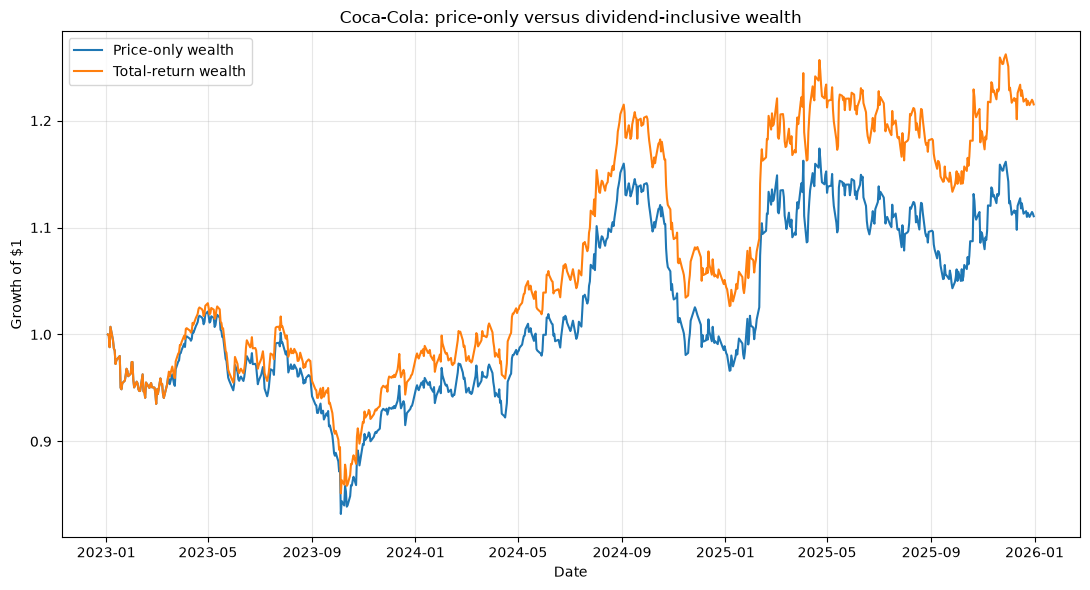

In [15]:
figure_path = (
    project_root
    / "reports"
    / "figures"
    / "ko_price_vs_total_return.png"
)
figure_path.parent.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    ko["date"],
    ko["price_growth_factor"],
    label="Price-only wealth",
)

ax.plot(
    ko["date"],
    ko["actions_growth_factor"],
    label="Total-return wealth",
)

ax.set_title(
    "Coca-Cola: price-only versus dividend-inclusive wealth"
)
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

### Interpretation

Over this sample, \$1 grows to approximately \$1.11 using price changes
alone and \$1.22 when dividends are included. Dividend-inclusive wealth is
about 9.4% larger than price-only wealth at the end of the period.

The gap reflects both the cash distributions and the subsequent compounding
of wealth after those distributions.

# 8. Dividend dates where price return gives the wrong sign


A price-only return can classify a date as a loss even when the shareholder's
total return is non-negative.

We count dates satisfying

$$
r_t^{\mathrm{price}}<0
\qquad\text{and}\qquad
r_t^{\mathrm{total}}\geq 0.
$$

It is a diagnostic showing that price movement
alone can give the wrong qualitative description of investor wealth.

In [16]:
ko["price_loss_but_nonnegative_total_return"] = (
    ko["price_return"].lt(0)
    & ko["total_return_from_actions"].ge(0)
)

dividend_events = ko.loc[ko["is_dividend_date"]].copy()

event_summary = pd.Series(
    {
        "number_of_dividend_dates": len(dividend_events),
        "negative_price_return_dates": (
            dividend_events["price_return"].lt(0).sum()
        ),
        "negative_total_return_dates": (
            dividend_events["total_return_from_actions"].lt(0).sum()
        ),
        "sign_reversal_dates": (
            dividend_events["price_loss_but_nonnegative_total_return"].sum()
        ),
        "sign_reversal_share": (
            dividend_events["price_loss_but_nonnegative_total_return"].mean()
        ),
        "mean_price_return": dividend_events["price_return"].mean(),
        "mean_total_return": (
            dividend_events["total_return_from_actions"].mean()
        ),
    }
)
event_summary

number_of_dividend_dates       12.000000
negative_price_return_dates     8.000000
negative_total_return_dates     4.000000
sign_reversal_dates             4.000000
sign_reversal_share             0.333333
mean_price_return              -0.005299
mean_total_return               0.002191
dtype: float64

In [17]:
sign_reversal_columns = [
    "date",
    "cash_dividend",
    "price_return",
    "total_return_from_actions",
    "dividend_return_component",
]

display(
    dividend_events.loc[
        dividend_events[
            "price_loss_but_nonnegative_total_return"
        ],
        sign_reversal_columns,
    ].style.format(
        {
            "cash_dividend": "${:.3f}",
            "price_return": "{:.3%}",
            "total_return_from_actions": "{:.3%}",
            "dividend_return_component": "{:.3%}",
        }
    )
)

,date,cash_dividend,price_return,total_return_from_actions,dividend_return_component
50,2023-03-16 00:00:00,$0.460,-0.215%,0.546%,0.761%
364,2024-06-14 00:00:00,$0.485,-0.699%,0.071%,0.770%
480,2024-11-29 00:00:00,$0.485,-0.543%,0.210%,0.753%
550,2025-03-14 00:00:00,$0.510,-0.661%,0.072%,0.733%


### Interpretation

Price return is negative on 8 of the 12 dividend dates, but total return is
negative on only 4.

Across all dividend dates, average price return is negative, while average
total return is positive.

# 9. Independent dividend-event verification

Adjusted prices are vendor-created analytical series, so it is useful to
verify the underlying corporate-action records against an independent data
source.

We compare yfinance and Alpha Vantage on:

1. ex-dividend date
2. cash dividend per share

In [18]:
alpha_path = (
    project_root
    / "data"
    / "raw"
    / "alphavantage"
    / "KO_dividends.csv"
)

alpha = pd.read_csv(alpha_path)

date_columns = [
    "ex_dividend_date",
    "declaration_date",
    "record_date",
    "payment_date",
]

for column in date_columns:
    alpha[column] = pd.to_datetime(
        alpha[column],
        errors="coerce",
    )

In [19]:
alpha_sample = (
    alpha.loc[
        alpha["ex_dividend_date"].between(
            "2023-01-01",
            "2025-12-31",
        ),
        [
            "ex_dividend_date",
            "declaration_date",
            "record_date",
            "payment_date",
            "amount",
        ],
    ]
    .sort_values("ex_dividend_date")
    .reset_index(drop=True)
)

yf_events = (
    ko.loc[
        ko["cash_dividend"].gt(0),
        ["date", "cash_dividend"],
    ]
    .rename(
        columns={
            "date": "ex_dividend_date",
            "cash_dividend": "yfinance_amount",
        }
    )
    .reset_index(drop=True)
)

vendor_comparison = yf_events.merge(
    alpha_sample,
    on="ex_dividend_date",
    how="outer",
    indicator=True,
    validate="one_to_one",
)

vendor_comparison = vendor_comparison.rename(
    columns={"amount": "alphavantage_amount"}
)

vendor_comparison["amount_difference"] = (
    vendor_comparison["yfinance_amount"]
    - vendor_comparison["alphavantage_amount"]
)

display(
    vendor_comparison[
        [
            "ex_dividend_date",
            "yfinance_amount",
            "alphavantage_amount",
            "amount_difference",
            "declaration_date",
            "record_date",
            "payment_date",
            "_merge",
        ]
    ]
)

,ex_dividend_date,yfinance_amount,alphavantage_amount,amount_difference,declaration_date,record_date,payment_date,_merge
0,2023-03-16,0.460,0.460,0.0,2023-02-16,2023-03-17,2023-04-03,both
1,2023-06-15,0.460,0.460,0.0,2023-04-26,2023-06-16,2023-07-03,both
2,2023-09-14,0.460,0.460,0.0,2023-07-19,2023-09-15,2023-10-02,both
3,2023-11-30,0.460,0.460,0.0,2023-10-19,2023-12-01,2023-12-15,both
4,2024-03-14,0.485,0.485,0.0,2024-02-15,2024-03-15,2024-04-01,both
5,2024-06-14,0.485,0.485,0.0,2024-05-02,2024-06-14,2024-07-01,both
6,2024-09-13,0.485,0.485,0.0,2024-07-29,2024-09-13,2024-10-01,both
7,2024-11-29,0.485,0.485,0.0,2024-10-17,2024-11-29,2024-12-16,both
8,2025-03-14,0.510,0.510,0.0,2025-02-20,2025-03-14,2025-04-01,both
9,2025-06-13,0.510,0.510,0.0,2025-05-01,2025-06-13,2025-07-01,both


In [20]:
assert vendor_comparison["_merge"].eq("both").all()

np.testing.assert_allclose(
    vendor_comparison["amount_difference"],
    0.0,
)

In [21]:
vendor_summary = pd.Series(
    {
        "yfinance_events": len(yf_events),
        "alphavantage_events": len(alpha_sample),
        "matched_event_dates": (
            vendor_comparison["_merge"].eq("both").sum()
        ),
        "maximum_amount_difference": (
            vendor_comparison["amount_difference"].abs().max()
        ),
    }
)

vendor_summary

yfinance_events              12.0
alphavantage_events          12.0
matched_event_dates          12.0
maximum_amount_difference     0.0
dtype: float64

### Interpretation

The two independent vendors report the same 12 ex-dividend dates and the
same dividend amounts for the selected period. This increases confidence
that the return differences observed earlier are not caused by missing or
incorrect yfinance dividend events.

The remaining small discrepancy between explicit-action returns and adjusted
close is therefore more plausibly associated with adjustment precision or
vendor transformation methodology.

In [22]:
comparison_path = (
    project_root
    / "reports"
    / "tables"
    / "ko_dividend_vendor_comparison.csv"
)

comparison_path.parent.mkdir(parents=True, exist_ok=True)

vendor_comparison.to_csv(
    comparison_path,
    index=False,
)

In [23]:
dividend_summary = pd.Series(
    {
        "number_of_dividend_dates": len(dividend_events),
        "sign_reversal_dates": (
            dividend_events[
                "price_loss_but_nonnegative_total_return"
            ].sum()
        ),
        "sign_reversal_share": (
            dividend_events[
                "price_loss_but_nonnegative_total_return"
            ].mean()
        ),
        "price_only_growth": (
            ko["price_growth_factor"].iloc[-1]
        ),
        "total_return_growth": (
            ko["actions_growth_factor"].iloc[-1]
        ),
        "total_wealth_premium_vs_price_only": (
            ko["actions_growth_factor"].iloc[-1]
            / ko["price_growth_factor"].iloc[-1]
            - 1.0
        ),
        "explicit_vs_adjusted_error_bps": (
            10_000
            * ko["cumulative_relative_error"].iloc[-1]
        ),
        "matched_vendor_event_dates": (
            vendor_comparison["_merge"].eq("both").sum()
        ),
        "maximum_vendor_amount_difference": (
            vendor_comparison[
                "amount_difference"
            ].abs().max()
        ),
    },
    name="value",
)

In [24]:
dividend_summary_path = (
    project_root
    / "reports"
    / "tables"
    / "ko_dividend_evidence.csv"
)

dividend_summary.to_frame().to_csv(
    dividend_summary_path
)


# Experiment B conclusion

Cash dividends separate quoted price movement from shareholder wealth.
In the synthetic example, a fall from \$100 to \$99 alongside a \$1
distribution produces a price return of $-1\%$, but a total return of zero.

For Coca-Cola over 2023–2025, explicit dividend accounting and adjusted-close
returns produced nearly identical total-return histories. Their cumulative
difference was approximately $-2.04$ basis points. The small daily
differences were concentrated on dividend dates, suggesting adjustment
precision or vendor methodology rather than missing ordinary price data.

Ignoring dividends entirely had a much larger economic effect. Price-only
wealth grew to approximately 1.111, while dividend-inclusive wealth grew to
approximately 1.215. On four of twelve dividend dates, price return was
negative while total return was non-negative.

Alpha Vantage independently confirmed all twelve yfinance ex-dividend dates
and amounts exactly. Therefore, the remaining adjusted-close discrepancy is
not explained by missing or mismatched dividend events.